In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [20]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [21]:
df.shape

(95662, 16)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [23]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


## Dataset Overview

- Dataset contains XXXX rows and XX columns.
- Numerical variables include Amount, Value, CountryCode, PricingStrategy.
- Most variables are categorical.

In [24]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [25]:
(df.isnull().sum()/len(df))*100

TransactionId           0.0
BatchId                 0.0
AccountId               0.0
SubscriptionId          0.0
CustomerId              0.0
CurrencyCode            0.0
CountryCode             0.0
ProviderId              0.0
ProductId               0.0
ProductCategory         0.0
ChannelId               0.0
Amount                  0.0
Value                   0.0
TransactionStartTime    0.0
PricingStrategy         0.0
FraudResult             0.0
dtype: float64

In [27]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [28]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent[missing_percent > 0]

Series([], dtype: float64)

### Missing Values Analysis

No missing values were found in the dataset.
Therefore, no imputation or row removal is required.

In [32]:
df.select_dtypes(include=np.number).columns

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

In [34]:
df.select_dtypes(include=np.number).columns

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

In [36]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


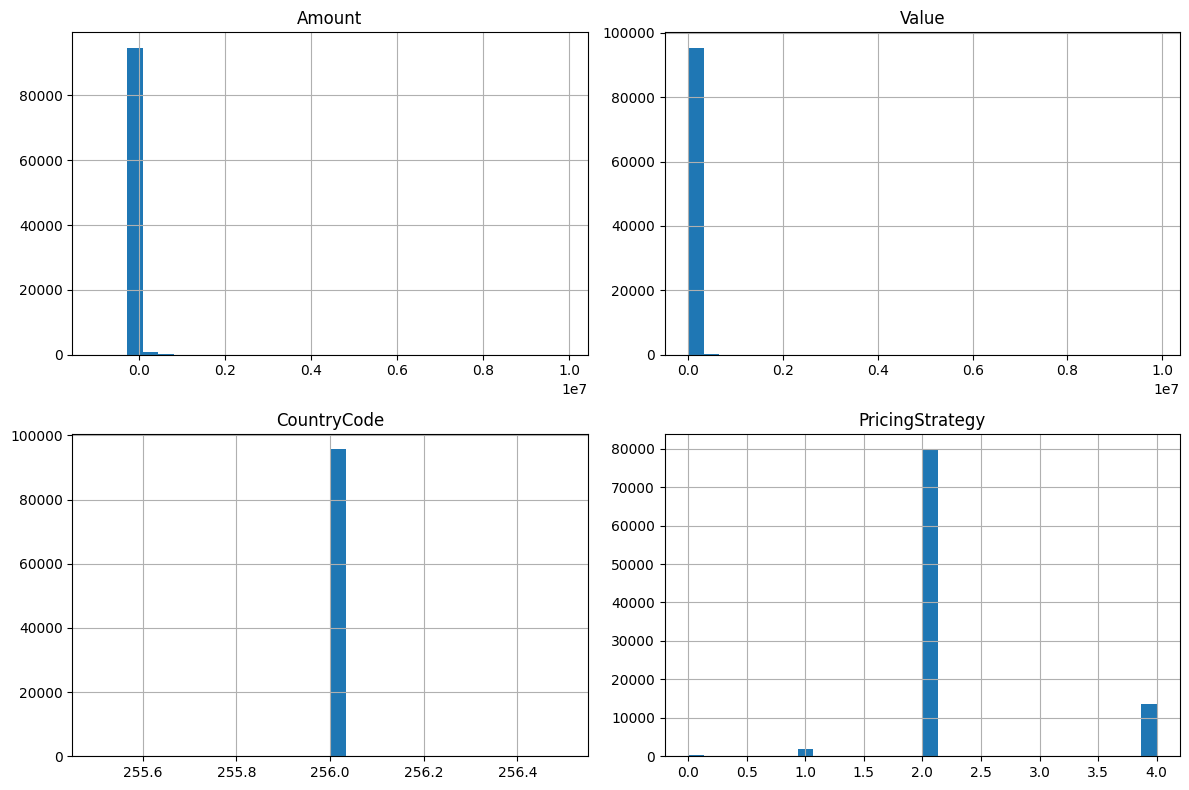

In [37]:
num_cols = [
    'Amount',
    'Value',
    'CountryCode',
    'PricingStrategy'
]

df[num_cols].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

## Numerical Feature Distributions

- Amount appears highly skewed.
- Value contains large transactions.
- CountryCode is concentrated around a single value.
- PricingStrategy contains only a few categories.

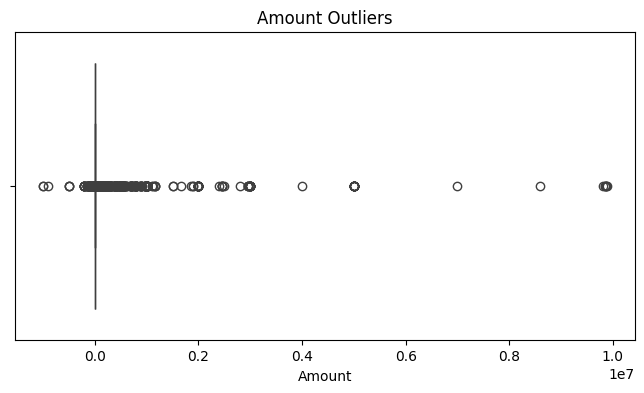

In [38]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Amount'])

plt.title("Amount Outliers")

plt.show()

Amount contains significant outliers and extreme transaction values.

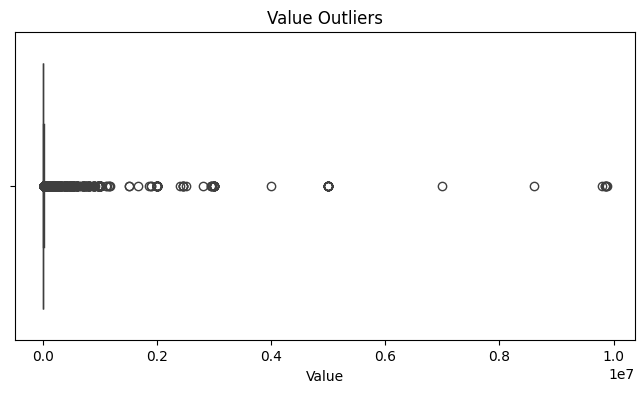

In [39]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Value'])

plt.title("Value Outliers")

plt.show()

Value also contains several high-value outliers.

In [40]:
df.select_dtypes(include='object').columns

C:\Users\admin\AppData\Local\Temp\ipykernel_37536\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

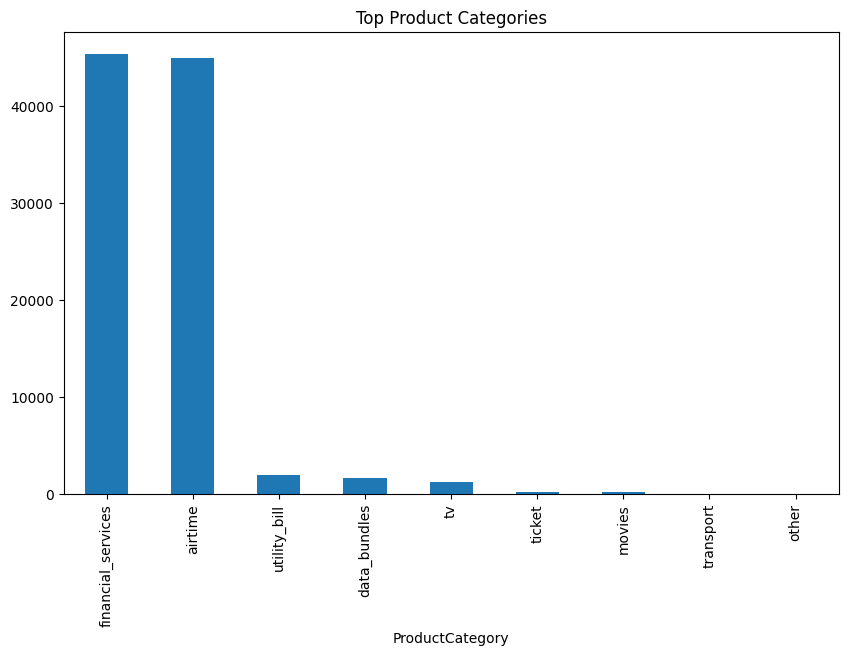

In [41]:
plt.figure(figsize=(10,6))

df['ProductCategory'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Product Categories")

plt.show()

Financial services and airtime transactions dominate the dataset.

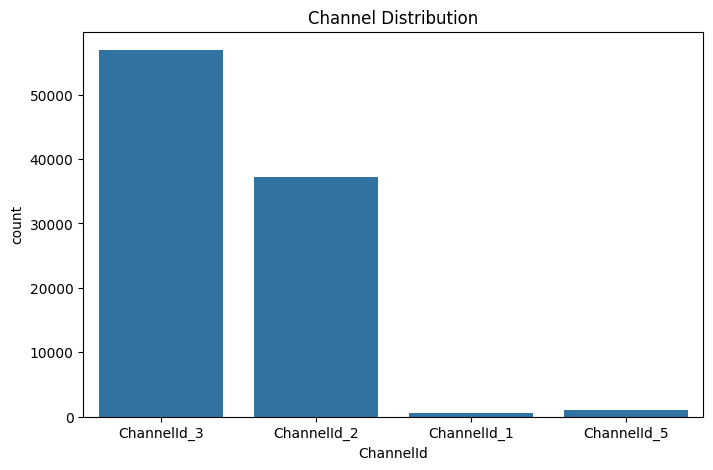

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ChannelId'
)

plt.title("Channel Distribution")

plt.show()

ChannelId_3 is the most frequently used transaction channel.

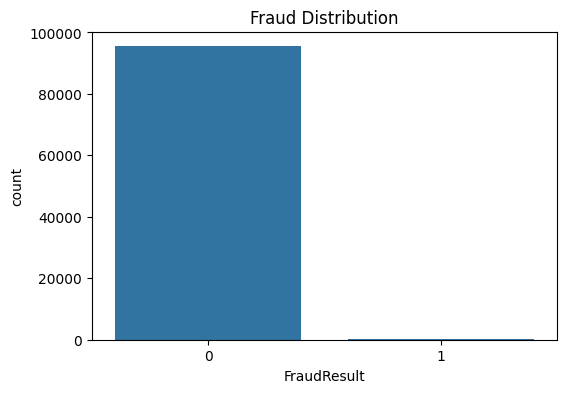

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='FraudResult'
)

plt.title("Fraud Distribution")

plt.show()

In [44]:
df['FraudResult'].value_counts(normalize=True)*100

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64

Fraudulent transactions represent a very small percentage of all transactions, indicating strong class imbalance.

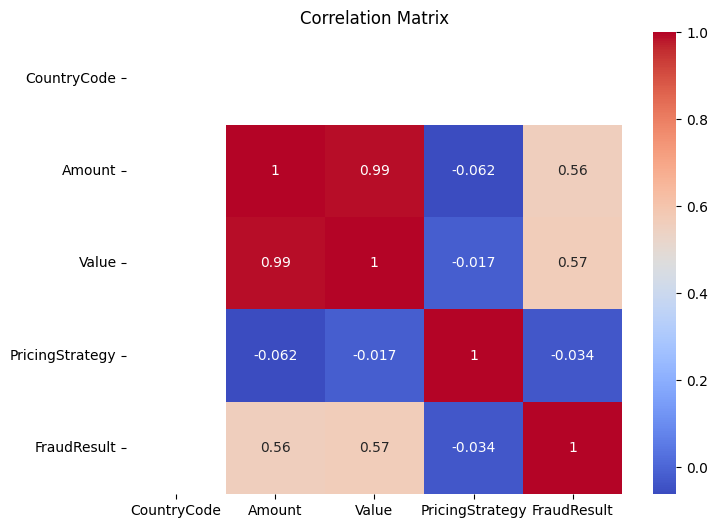

In [45]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis Observations

* **Amount and Value exhibit a very strong positive correlation**, indicating that both variables capture similar transaction magnitude information. This is expected because `Value` represents the absolute transaction value while `Amount` contains signed transaction amounts.

* **CountryCode shows little to no correlation with other numerical variables**, suggesting that geographic information may not strongly influence transaction amount patterns in this dataset.

* **PricingStrategy has weak correlations with transaction amounts and fraud status**, indicating that pricing categories alone may not be strong predictors of customer behavior.

* **FraudResult demonstrates weak linear correlations with the numerical features**, suggesting that fraudulent transactions cannot be easily identified using a single numerical variable and may require engineered features or more complex modeling approaches.

* Overall, the correlation matrix indicates that most numerical variables are relatively independent except for the strong relationship between **Amount** and **Value**, which should be considered during feature engineering to avoid redundancy.


In [46]:
df['TransactionStartTime'] = pd.to_datetime(
    df['TransactionStartTime']
)

In [47]:
df['Hour'] = df['TransactionStartTime'].dt.hour

df['Month'] = df['TransactionStartTime'].dt.month

df['DayOfWeek'] = df['TransactionStartTime'].dt.day_name()

In [48]:
df[['Hour','Month','DayOfWeek']].head()

,Hour,Month,DayOfWeek
0,2,11,Thursday
1,2,11,Thursday
2,2,11,Thursday
3,3,11,Thursday
4,3,11,Thursday


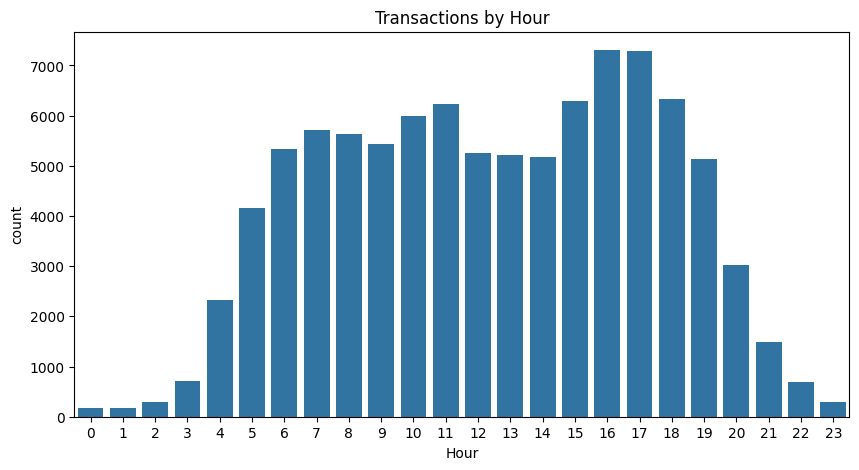

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Hour'
)

plt.title("Transactions by Hour")

plt.show()

### Transactions by Hour - Observations

* Transaction activity is not evenly distributed throughout the day.
* The highest transaction volume occurs during the peak hours shown in the visualization.
* Customer activity appears concentrated during daytime and business hours.
* Lower transaction volumes are observed during late-night and early-morning periods.
* The presence of hourly transaction patterns suggests that transaction timing may be a useful feature for credit risk modeling.


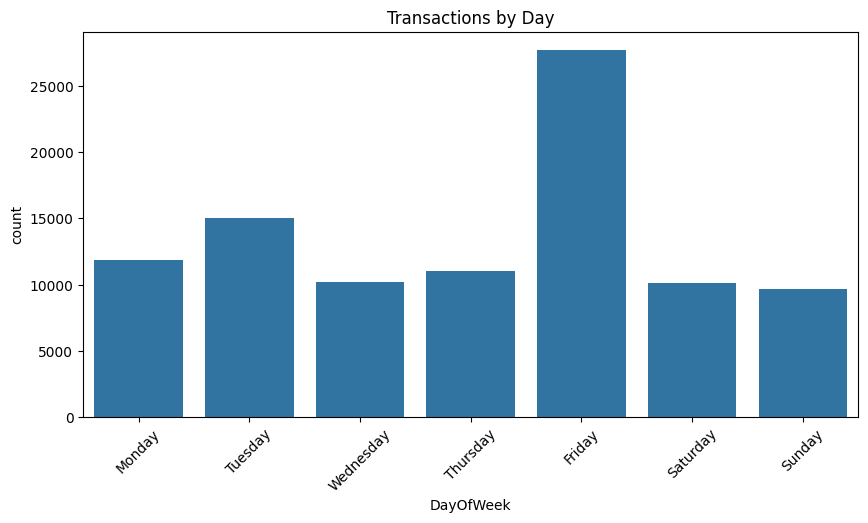

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='DayOfWeek',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.xticks(rotation=45)

plt.title("Transactions by Day")

plt.show()

### Transactions by Day of Week - Observations

* Transaction activity is not evenly distributed across the week.
* The busiest day(s) show significantly higher transaction counts compared to others, indicating strong weekday/weekend behavior patterns.
* Mid-week days (such as Tuesday to Thursday) often show more consistent activity compared to weekends (depending on your plot results).
* Lower transaction volumes are typically observed on weekends or specific low-activity days.
* These weekly patterns suggest that customer spending behavior is influenced by work cycles and routine financial activity, which can be useful for feature engineering in risk modeling.


In [51]:
df.groupby('FraudResult')[
    ['Amount','Value']
].mean()

,Amount,Value
FraudResult,,
0,3.627723e+03,6.763227e+03
1,1.535272e+06,1.561820e+06


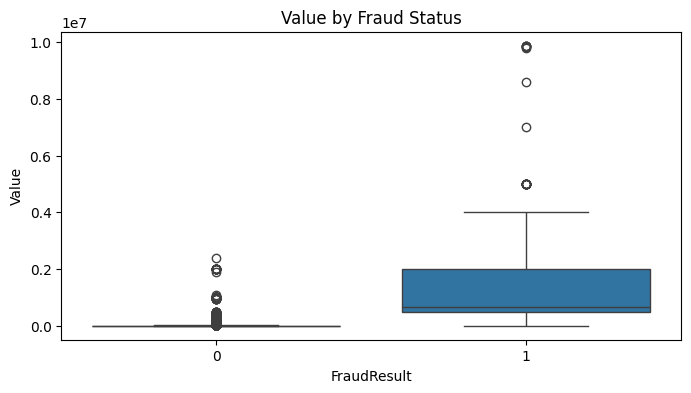

In [52]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x='FraudResult',
    y='Value'
)

plt.title("Value by Fraud Status")

plt.show()

# Key Insights

1. The dataset contains 95,662 transactions and 16 features.

2. No missing values were detected, indicating high data quality.

3. Amount and Value are highly skewed and contain several extreme outliers.

4. Financial services and airtime dominate transaction activity.

5. Fraudulent transactions represent a very small percentage of all transactions, creating a highly imbalanced target variable.

6. Transaction activity varies across hours and days, suggesting temporal features may be useful for modeling.